This script is a modified copy of 2_1_grounding_detection.ipynb that generates illustrations to highlight characteristic observation of grounding events

# Datasets Preparation

In [1]:
verbose = False
%run ./2_0_datasets_preparation.ipynb

START DATASETS PREPARATION
verbose is False
>> imports
>> load trajectories
>> load bathymetry
>> load SWAN waterlevel
>> load wind
>> preprocessing bathymetry
resolution original dataset x~20.324686m and y~20.324707m
resolution downscaled x~101.718607m and y~101.623535m
>> preprocessing wind
>> defining misc shared methods
DONE DATASETS PREPARATION


# Parameters

In [6]:
trajectory_parameters = [[1,0.00]]
grounding_directional_angle_per_step_deg = 57.6 #TODO value [86,84,82,77,72,57.6,84,82,77,72,57.6]
grounding_timewindows_minutes = [180]
verbose = True
show_detailed_plots = True # long output
plots_output_root_dir = "plot/"

# 2: Grounding Detection

## Methods

In [7]:
import matplotlib.pyplot as plt

def plot_timelines(tr, deived_timelines, statistics_parameters, file_label=None):
    i_dis, i_dir, st_dis, st_dir, st, sec_dis, sec_dir, sec, dir_change, hNAP, wl, wl_surroundings, wd, winding_numbers = deived_timelines
    grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step = statistics_parameters

    t_h = tr.t.values/(60*60) # times in hours
    N = t_h.shape[0]

    N_plots = 4
    fig, axs = plt.subplots(N_plots,figsize=(12,8))

    ip = 0
    axs[ip].plot(t_h,np.rad2deg(dir_change),c='green')
    axs[ip].set_xlabel('time since release [h]', loc='right')
    axs[ip].set_ylabel('directional\nchange [deg]')
    axs[ip].set_yticks(np.linspace(-180,180,5))
    axs[ip].set_ylim([-180,180])

    ip += 1
    axs[ip].plot(t_h,tr.v.values,c='red')
    axs[ip].set_xlabel('time since release [h]', loc='right')
    axs[ip].set_ylabel('speed [m/s]')
    axs[ip].set_yticks(np.linspace(0,0.75,4))
    axs[ip].set_ylim([-0.05,0.9])

    ip += 1
    axs[ip].plot(t_h,wl,c='blue')
    axs[ip].set_yticks(np.linspace(-1,1,3))
    axs[ip].set_xlabel('time since release [h]', loc='right')
    axs[ip].set_ylabel('waterlevel NAP [m]')
    axs[ip].set_ylim([-1.2,1.1])

    ip += 1
    axs[ip].plot(t_h, wd,c='blue')
    axs[ip].set_ylim([-1.,17.])
    axs[ip].set_yticks(np.linspace(0,15,4))
    axs[ip].set_xlabel('time since release [h]', loc='right')
    axs[ip].set_ylabel('waterdepth\nseabed level [m]')

    ith0, ith1 = np.argmin(np.abs(153.0-t_h)), np.argmin(np.abs(173.0-t_h))
    for ip in range(N_plots):
      axs[ip].set_xlim([t_h[ith0],t_h[ith1]])
      major_ticks = np.round(np.linspace(t_h[ith0],t_h[ith1],11),decimals=1)
      minor_ticks = np.round(np.linspace(t_h[ith0],t_h[ith1],41),decimals=1)
      axs[ip].set_xticks(major_ticks)
      axs[ip].set_xticks(minor_ticks, minor=True)
      axs[ip].grid(which='major', axis='both', c='darkgray')
      axs[ip].grid(which='minor', alpha=0.2)
      ylim = axs[ip].get_ylim()
      t_range = np.linspace(t_h[ith0],t_h[ith1],10000)
      axs[ip].scatter(t_range, ylim[0]*np.ones(t_range.shape[0]), c=t_range, cmap=mpl.colormaps['tab10'], s=10, zorder=10)
      axs[ip].set_ylim(ylim)
    label = ['D','W','B','O']
    color = ['lime','cyan','orange','magenta']
    for il in range(len(label)):
      entries, ne = get_manual_labels_and_indices_where(tr, label[il])
      inds = entries.ind_start.values
      for ii in range(ne):
        for ip in range(N_plots):
          axs[ip].axvline(t_h[inds[ii]],c=color[il],linestyle="--")
          if label[il] in ['D','W','B']:
            ylim = axs[ip].get_ylim()
            offset = 0 #label[il] == 'W'
            axs[ip].text(t_h[inds[ii]], ylim[1]+(0.025*(1+3*offset))*(ylim[1]-ylim[0]), "%.1fh"%float(tr.dt_section[inds[ii]]/(60*60)), fontsize=7, bbox={'facecolor':'white','pad':0,'lw':0})
    plt.tight_layout()
    plt.savefig("plot/groundingdetection/illustration_%s_timelines.png"%file_label) if file_label else None
    plt.show() if show_detailed_plots else None

    # plot trace for reference
    fig, ax = utils.map_plot(figsize=(12,12))
    ax.plot(tr.lon.values[ith0:ith1+1], tr.lat.values[ith0:ith1+1], c='black', lw=1, zorder=101)
    ax.scatter(tr.lon.values[ith0:ith1+1], tr.lat.values[ith0:ith1+1], c=tr.t.values[ith0:ith1+1], cmap=mpl.colormaps['tab10'], s=20, zorder=102)
    plt.title("irecord %d its %d" % (tr.attrs['i_record'], tr.attrs['i_ts']))
    plt.savefig("plot/groundingdetection/illustration_%s_map.png"%file_label) if file_label else None #TODO paraeterize path
    plt.show() if show_detailed_plots else None

    axlon = [5.69933,5.707]
    axlat = [53.46325,53.46595]
    dlon_dlat = [1.63e-04*10, 9.00e-05*10]
    fig, ax = utils.map_plot(figsize=(6,2))
    ax.plot(tr.lon.values[ith0:ith1+1], tr.lat.values[ith0:ith1+1], c='black', lw=1, zorder=101)
    ax.scatter(tr.lon.values[ith0:ith1+1], tr.lat.values[ith0:ith1+1], c=tr.t.values[ith0:ith1+1], cmap=mpl.colormaps['tab10'], s=20, zorder=102)
    ax.plot([5.706,5.706],[53.4635,53.4635+dlon_dlat[1]],c='red',lw=3,zorder=100)
    ax.plot([5.706,5.706-dlon_dlat[0]],[53.4635,53.4635],c='red',lw=3,zorder=100)
    ax.text(5.706-dlon_dlat[0]/1.5, 53.4635+dlon_dlat[1]/4, "100m", fontsize=9, color='red')
    ax.text(5.706+dlon_dlat[0]/8, 53.4635+dlon_dlat[1]/2, "100m", fontsize=9, color='red')
    plt.title("irecord %d its %d" % (tr.attrs['i_record'], tr.attrs['i_ts']))
    ax.set_xlim(axlon)
    ax.set_ylim(axlat)
    ax.set_aspect('equal')
    plt.savefig("plot/groundingdetection/illustration_%s_map_zoom.png"%file_label) if file_label else None #TODO paraeterize path
    plt.show() if show_detailed_plots else None

    axlon = [5.6995,5.6999]
    axlat = [53.46345,53.46365]
    dlon_dlat = [1.63e-04/2., 9.00e-05/2.]
    fig, ax = utils.map_plot(figsize=(4,1.5))
    ax.plot(tr.lon.values[ith0:ith1+1], tr.lat.values[ith0:ith1+1], c='black', lw=1, zorder=101)
    ax.scatter(tr.lon.values[ith0:ith1+1], tr.lat.values[ith0:ith1+1], c=tr.t.values[ith0:ith1+1], cmap=mpl.colormaps['tab10'], s=20, zorder=102)
    ax.plot([axlon[0]+0.00035,axlon[0]+0.00035],[axlat[0]+0.000025,axlat[0]+0.000025+dlon_dlat[1]],c='red',lw=3,zorder=100)
    ax.plot([axlon[0]+0.00035,axlon[0]+0.00035-dlon_dlat[0]],[axlat[0]+0.000025,axlat[0]+0.000025],c='red',lw=3,zorder=100)
    ax.text(axlon[0]+0.00035-dlon_dlat[0]/1.5, axlat[0]+0.000025-dlon_dlat[1]/2.5, "5m", fontsize=9, color='red')
    ax.text(axlon[0]+0.00035+dlon_dlat[0]/8, axlat[0]+0.000025+dlon_dlat[1]/2, "5m", fontsize=9, color='red')
    plt.title("irecord %d its %d" % (tr.attrs['i_record'], tr.attrs['i_ts']))
    ax.set_xlim(axlon)
    ax.set_ylim(axlat)
    ax.set_aspect('equal')
    plt.savefig("plot/groundingdetection/illustration_%s_map_zoomx2.png"%file_label) if file_label else None #TODO paraeterize path
    plt.show() if show_detailed_plots else None

# Computation

## Aux methods

In [8]:
surroundings_distance_meters = 1000. # the local waterlevels are resampled at this distance and added to the plots to gve an impression of the reliability/stability of this sampling TODO add to global parameters?

def compute_statistics(trajectories, N_traj, grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step, file_label=None):
  print(file_label) if file_label else None
  # variables for statistics
  cum_confusion_mat_per_index = np.zeros((N_traj,2,2))
  cum_confusion_mat_per_section = np.zeros((N_traj,2,2))
  means_dt = np.zeros(N_traj)
  means_timewindows_nt = np.zeros(N_traj)

  for i_tr, tr in enumerate(trajectories):
      if i_tr!=28:
        continue
      N = tr.lon.values.shape[0]

      # preparations for grounding indices computations
      displacement_distance, directional_angle_average = np.zeros(N), np.zeros(N)
      abs_directional_change, directional_change, winding_numbers = np.zeros(N), np.zeros(N), np.zeros((N,2))
      displacement_timewindow_nt, directional_timewindow_nt = np.zeros(N), np.zeros(N)
      for i in range(N-1):
        abs_directional_change[i] = utils.abs_directional_change_rad(tr.alp_noise_augmented.values[i],tr.alp_noise_augmented.values[i+1])
        directional_change[i] = utils.directional_change_rad(tr.alp_noise_augmented.values[i],tr.alp_noise_augmented.values[i+1])
        winding_numbers[i+1,0] = winding_numbers[i,0] + utils.directional_change_rad(tr.alp.values[i],tr.alp.values[i+1])
        winding_numbers[i+1,1] = winding_numbers[i,1] + utils.directional_change_rad(tr.alp_noise_augmented.values[i],tr.alp_noise_augmented.values[i+1])

      # compute grounding indices
      grounding_index_displacement, grounding_index_directional = np.full(N, np.nan), np.full(N, np.nan)
      for i in range(N):
        t = tr.time.values[i]
        # statistic from displacement
        it, nt, _, _, _ = utils.get_nonuniform_range_window(tr.time.values, t, grounding_displacement_timewindow_minutes*60)
        displacement_timewindow_nt[i] = nt
        displacement_distance[i] = utils.distance_coords_to_meters(tr.lon.values[it], tr.lat.values[it], tr.lon.values[it+nt], tr.lat.values[it+nt])
        D = displacement_distance[i]
        C_D = grounding_displacement_caracteristic_distance
        grounding_index_displacement[i] = C_D / (D + C_D)
        # statistic from direction
        it, nt, _, _, _ = utils.get_nonuniform_range_window(tr.time.values, t, grounding_directional_timewindow_minutes*60)
        directional_timewindow_nt[i] = nt
        directional_angle_average[i] = np.sum(abs_directional_change[it:it+nt])/nt
        A = directional_angle_average[i]
        C_A = grounding_directional_angle_per_step
        grounding_index_directional[i] = A / (A + C_A)

      # compute grounding thresholds
      grounded_state_displacement = displacement_distance < grounding_displacement_caracteristic_distance
      grounded_state_directional = directional_angle_average > grounding_directional_angle_per_step
      grounded_state = np.logical_and(grounded_state_displacement, grounded_state_directional)
      grounded_sections_displacement, grounded_sections_directional = np.full(N, False), np.full(N, False)
      for i in range(N):
        t = tr.time.values[i]
        it, nt, _, _, _ = utils.get_nonuniform_range_window(tr.time.values, t, grounding_displacement_timewindow_minutes*60)
        grounded_sections_displacement[it:it+nt] = np.logical_or(grounded_sections_displacement[it:it+nt], grounded_state_displacement[i])
        grounded_sections_directional[it:it+nt] = np.logical_or(grounded_sections_directional[it:it+nt], grounded_state_directional[i])
      grounded_sections = np.logical_and(grounded_sections_displacement, grounded_sections_directional)

      # compute waterdepth
      hNAP, wl, wl_surroundings = np.zeros(N), np.zeros(N), np.zeros((4,N))
      pos_flat = utils.flatten_coords_deg_NE(np.array([tr.lon.values,tr.lat.values]).T)
      for i in range(N):
        wl[i], _, wl_surroundings[:,i] = utils.sample_nearest_mesh_value(waterleveldata,{"lon":tr.lon.values[i], "lat":tr.lat.values[i], "time":tr.time.values[i]},surroundings_distance_meters)
        hNAP[i], _, _, _ = utils.get_closest_eulerian_fast_value_from_mesh(pos_flat[i], bathymetry["vals"], bathymetry["coords_mesh_flat"])
      wd = -hNAP+wl

      means_dt[i_tr] = tr.dt.mean()
      means_timewindows_nt[i_tr] = np.mean([np.mean(displacement_timewindow_nt), np.mean(directional_timewindow_nt)])

      deived_timelines = [
          grounding_index_displacement, grounding_index_directional, grounded_state_displacement, grounded_state_directional, grounded_state, grounded_sections_displacement, grounded_sections_directional, grounded_sections,
          directional_change, hNAP, wl, wl_surroundings, wd, winding_numbers
      ]
      statistics_parameters = [grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step]
      print("avg nt dis %f, avg nt dir %f, mean dt %.1fmin" % (np.mean(displacement_timewindow_nt), np.mean(directional_timewindow_nt), means_dt[i_tr]/60.))
      plot_timelines(tr, deived_timelines, statistics_parameters, file_label="%s_trajectory_%d"%(file_label,i_tr))

  return cum_confusion_mat_per_index, cum_confusion_mat_per_section, mean_timewindow_nt, mean_dt

## Running the scripts above with the sample trajectory

data/out/trajectories/sample_interval_1_rnd_drop_fraction_0.00/
2026-05-19 14:16:05.064339
sample_interval_1_rnd_drop_fraction_0.00_timewindow_displacement_minutes_180_timewindow_directional_minutes_180
avg nt dis 34.021498, avg nt dir 34.021498, mean dt 5.2min


/var/folders/34/nx9zlnqn1z1cr2gtrfzmz7vw0000gp/T/ipykernel_57751/2961203830.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


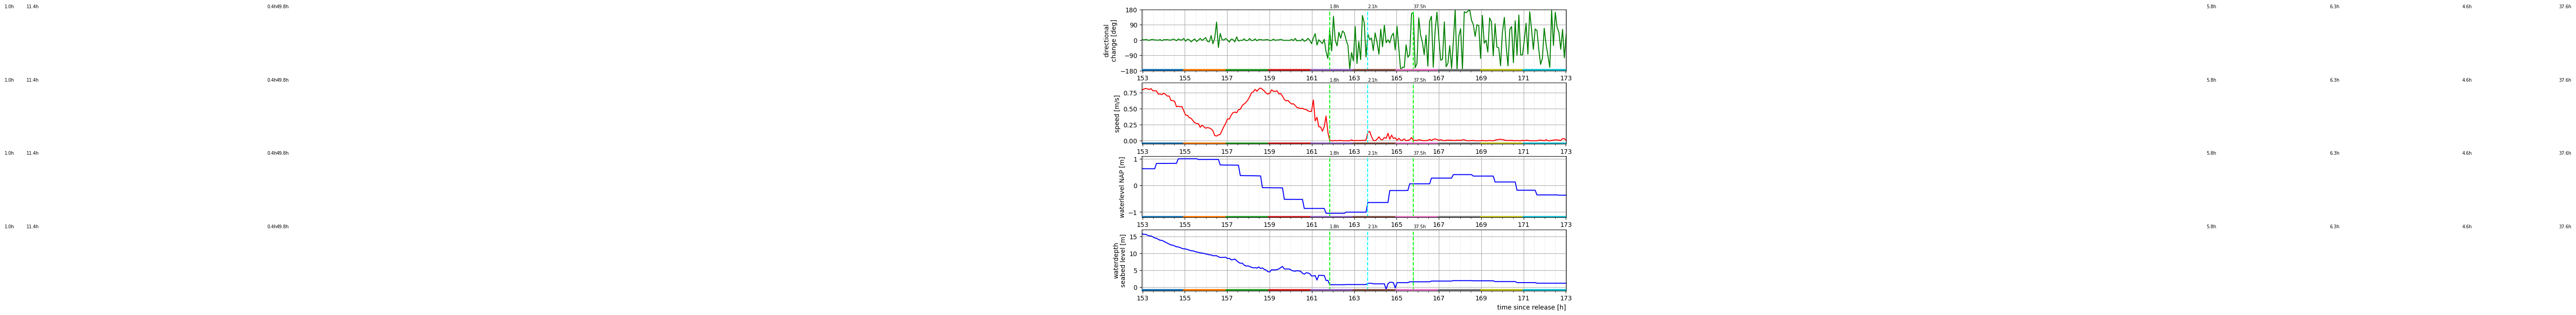

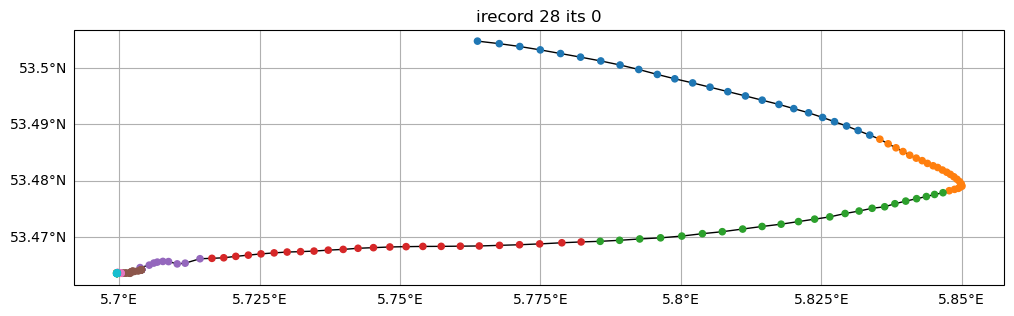

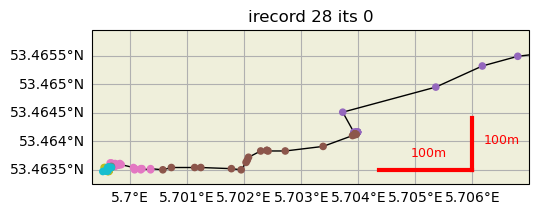

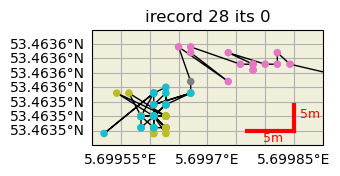

NameError: name 'mean_timewindow_nt' is not defined

In [9]:
import datetime
import utils

trajectories, N_traj = load_trajectories("data/out/sample_interval_%d_rnd_drop_fraction_%.2f/"%tuple(trajectory_parameters[0]))

tp = trajectory_parameters[0]
input_path = "data/out/trajectories/sample_interval_%d_rnd_drop_fraction_%.2f/"%tuple(tp)
print(input_path)
print(datetime.datetime.now())
trajectories, N_traj = load_trajectories(input_path)
pos_stdev = trajectories[0].attrs["stdev_position_meters"]
gtw = grounding_timewindows_minutes[0]
grounding_displacement_timewindow_minutes = gtw
grounding_displacement_caracteristic_distance = pos_stdev
grounding_directional_timewindow_minutes = gtw
grounding_directional_angle_per_step = np.deg2rad(grounding_directional_angle_per_step_deg)
file_label = "sample_interval_%d_rnd_drop_fraction_%.2f_timewindow_displacement_minutes_%d_timewindow_directional_minutes_%d"%(tp[0],tp[1],gtw,gtw)
compute_statistics(trajectories, N_traj, grounding_displacement_timewindow_minutes, grounding_displacement_caracteristic_distance, grounding_directional_timewindow_minutes, grounding_directional_angle_per_step, file_label=file_label)